# PflegeOptix — Sprint 1: Data Cleaning & Feature Engineering

This notebook builds the complete data pipeline for the PflegeOptix project.  
It merges **3 data sources** into a single, model-ready master dataset:

| Step | Source | Purpose |
|------|--------|---------|
| 1 | Destatis Population (10 files) | 65+ population per district (2015–2024) |
| 2 | Pflegestatistik `22411-01-02-4.csv` | Care home beds & personnel (biennial) |
| 3 | INKAR 2025 (6.7 GB) | 15 socioeconomic indicators |

**Target variable:** `Versorgungsquote` = FullStay_Beds / Population_65+  
**Output:** `dataset/processed/master_dataset.csv` (lean, model-ready)

---
## Step 1: Load & Clean Population Data (2015–2024)
Load 10 annual Destatis CSV files, standardize AGS codes, filter to all 16 Bundesländer,  
and aggregate age-group rows into a single 65+ total per district per year.

In [1]:
import glob
import os
import pandas as pd

# -------------------------------------------------------------------
# 1a. Iterate over all 10 population files and concatenate into one DF
# -------------------------------------------------------------------
pop_file_pattern = '../../dataset/raw/population/12411-04-02-4_*.csv'
pop_files = glob.glob(pop_file_pattern)

df_pop_list = []

for file in pop_files:
    # Skip 7 metadata header rows and 4 copyright footer rows (Destatis standard)
    df_temp = pd.read_csv(file, sep=';', encoding='latin-1',
                          skiprows=7, skipfooter=4, engine='python', header=None)
    df_temp.columns = ['AGS', 'Region', 'Age_Group', 'Total', 'Male', 'Female']

    # Extract year from filename (e.g., '_15.csv' -> 2015)
    year_str = os.path.basename(file).split('_')[-1][:2]
    df_temp['Year'] = 2000 + int(year_str)

    df_pop_list.append(df_temp)

df_population = pd.concat(df_pop_list, ignore_index=True)
print(f"Loaded {len(pop_files)} files | {len(df_population):,} total rows")

Loaded 10 files | 430,400 total rows


In [2]:
# -------------------------------------------------------------------
# 1b. Standardize AGS codes (all 16 Bundesländer)
# -------------------------------------------------------------------
df_pop_clean = df_population.copy()

# Ensure AGS is a zero-padded 5-digit string (e.g., '5111' -> '05111')
df_pop_clean['AGS'] = (df_pop_clean['AGS'].astype(str).str.strip()
                        .apply(lambda x: x.split('.')[0].zfill(5)))

# No state filter — include all 16 Bundesländer

# Convert population counts to numeric (coerce '-' and blanks to NaN)
for col in ['Total', 'Male', 'Female']:
    df_pop_clean[col] = pd.to_numeric(df_pop_clean[col], errors='coerce')

print(f"Rows after cleaning: {len(df_pop_clean):,}")


Rows after cleaning: 430,400


In [3]:
# -------------------------------------------------------------------
# 1c. Aggregate all 65+ age groups into 1 row per AGS per Year
# -------------------------------------------------------------------

# Remove summary rows ("Insgesamt") to avoid double counting
df_pop_65plus = df_pop_clean[
    ~df_pop_clean['Age_Group'].str.contains('Insgesamt', na=False, regex=False)
]

# Aggregate: sum all age-group rows within each district-year
df_pop_grouped = df_pop_65plus.groupby(['AGS', 'Region', 'Year']).agg({
    'Total': 'sum',
    'Male':  'sum',
    'Female': 'sum'
}).reset_index()

# Remove "Ghost Districts" (population = 0 due to 2008 Saxony Kreisreform)
df_pop_grouped = df_pop_grouped[df_pop_grouped['Total'] > 0].copy()

print(f"Population base ready: {len(df_pop_grouped):,} rows")
print(f"Unique districts: {df_pop_grouped['AGS'].nunique()}")
print(f"Years covered: {sorted(df_pop_grouped['Year'].unique())}")
display(df_pop_grouped.head(3))

Population base ready: 4,513 rows
Unique districts: 462
Years covered: [np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024)]


,AGS,Region,Year,Total,Male,Female
0,00001,Schleswig-Holstein,2015,2858714.0,1399458.0,1459256.0
1,00001,Schleswig-Holstein,2016,2881926.0,1412665.0,1469261.0
2,00001,Schleswig-Holstein,2017,2889821.0,1416535.0,1473286.0


---
## Step 2: Load Pflegestatistik & Compute Target Variable
Load care facility statistics (beds, homes, personnel).  
Inner-join with population to create `Versorgungsquote` (care supply ratio).  

**Note:** Patient counts are unavailable at Landkreis level.  
We use `FullStay_Beds` as a proxy (occupancy rate > 90% in Germany).

In [4]:
# -------------------------------------------------------------------
# 2a. Load and clean the Pflegestatistik CSV
# -------------------------------------------------------------------
file_path_pflege = '../../dataset/raw/22411-01-02-4.csv'
df_pflege = pd.read_csv(file_path_pflege, sep=';', encoding='latin-1',
                        skiprows=8, skipfooter=4, engine='python', header=None)

# Assign readable column names matching the 9-column structure
df_pflege.columns = [
    'Date', 'AGS', 'Region',
    'Ambulant_Services', 'Ambulant_Personnel',
    'Homes', 'Total_Beds', 'FullStay_Beds', 'Home_Personnel'
]

# Extract year from date string (e.g., '31.12.2023' -> 2023)
df_pflege['Year'] = pd.to_datetime(df_pflege['Date'], format='%d.%m.%Y', errors='coerce').dt.year

# Standardize AGS to 5-digit string (all states)
df_pflege['AGS'] = (df_pflege['AGS'].astype(str).str.strip()
                    .apply(lambda x: x.split('.')[0].zfill(5)))
df_pflege = df_pflege.copy()  # No state filter — use all districts

# Convert numeric columns (coerce '-' -> NaN) and drop invalid rows
for col in ['Homes', 'Total_Beds', 'FullStay_Beds', 'Home_Personnel']:
    df_pflege[col] = pd.to_numeric(df_pflege[col], errors='coerce')
df_pflege = df_pflege.dropna(subset=['FullStay_Beds'])
df_pflege = df_pflege[df_pflege['FullStay_Beds'] > 0]

# Keep only needed columns
df_pflege_clean = df_pflege[['AGS', 'Year', 'Region',
                             'Homes', 'FullStay_Beds', 'Home_Personnel']].copy()

print(f"Pflegestatistik cleaned: {len(df_pflege_clean):,} rows")
display(df_pflege_clean.head(3))

Pflegestatistik cleaned: 2,299 rows


,AGS,Year,Region,Homes,FullStay_Beds,Home_Personnel
0,000DG,2023,Deutschland,16505.0,874562.0,817711.0
1,00001,2023,Schleswig-Holstein,693.0,37394.0,31445.0
2,01001,2023,"Flensburg, kreisfreie Stadt",18.0,1043.0,913.0


In [5]:
# -------------------------------------------------------------------
# 2b. Inner Join population + care data -> compute Versorgungsquote
# -------------------------------------------------------------------

# Drop Region from population to avoid duplicate column names after merge
df_pop_to_join = df_pop_grouped.drop(columns=['Region'])

# Inner Join: only keeps AGS-Year pairs present in BOTH datasets
# (automatically handles the biennial Pflegestatistik reporting cycle)
df_master = pd.merge(df_pflege_clean, df_pop_to_join,
                     on=['AGS', 'Year'], how='inner')

# Compute the target variable: Care Supply Ratio
# Versorgungsquote = FullStay_Beds / Total_Population_65+
df_master['Versorgungsquote'] = df_master['FullStay_Beds'] / df_master['Total']

# Reorder columns for readability
df_master = df_master[[
    'AGS', 'Region', 'Year',
    'Total', 'Male', 'Female',
    'Homes', 'FullStay_Beds', 'Home_Personnel',
    'Versorgungsquote'
]]

print(f"Master dataset assembled: {len(df_master):,} rows x {df_master.shape[1]} columns")
display(df_master.head(3))

Master dataset assembled: 2,251 rows x 10 columns


,AGS,Region,Year,Total,Male,Female,Homes,FullStay_Beds,Home_Personnel,Versorgungsquote
0,000DG,Deutschland,2023,83456045.0,41161931.0,42294114.0,16505.0,874562.0,817711.0,0.010479
1,00001,Schleswig-Holstein,2023,2953202.0,1443888.0,1509314.0,693.0,37394.0,31445.0,0.012662
2,01001,"Flensburg, kreisfreie Stadt",2023,96431.0,47553.0,48878.0,18.0,1043.0,913.0,0.010816


---
## Step 3: Extract INKAR Socioeconomic Features (6.7 GB)
Read the massive INKAR indicator file in memory-safe chunks.  
Extract 15 indicators relevant to elderly care demand, then pivot to wide format.

In [6]:
# -------------------------------------------------------------------
# 3a. Define the 15 target INKAR indicators
# -------------------------------------------------------------------
target_indicators = {
    # Healthcare infrastructure
    'q_bev_arzt':      'Residents_per_Doctor',
    'q_hausarzt_bev':  'GPs_per_Pop',
    'q_kb_bev':        'Hospital_Beds_per_1k',
    'q_pflpl_bev':     'Care_Home_Places_per_Pop',
    'q_pers_pd_pfl':   'Care_Service_Personnel',
    'q_pers_ph_pfl':   'Care_Home_Personnel',

    # Demographics & social structure
    'q_bev_fl':        'Population_Density',
    'q_HH1':           'Single_Person_Households_Pct',
    'q_tod_u70':       'Premature_Mortality',

    # Economy & purchasing power
    'q_kaufkraft':     'Purchasing_Power',
    'q_ewp_f':         'Female_Employment_Rate',
    'q_svw_5564':      'Employment_Rate_55plus',
    'q_SGBII':         'Welfare_Rate_SGBII',
    'q_Schuldner':     'Debtor_Rate',
    'q_pendlersaldo':  'Commuter_Balance',
}

target_kuerzel = list(target_indicators.keys())
print(f"Selected {len(target_kuerzel)} indicators for extraction")

Selected 15 indicators for extraction


In [7]:
# -------------------------------------------------------------------
# 3b. Chunked extraction from INKAR (memory-safe for 6.7 GB file)
# -------------------------------------------------------------------
chunk_size = 500_000
chunks_collected = []

reader = pd.read_csv(
    '../../dataset/raw/inkar_features/inkar_2025.csv',
    sep=';', encoding='latin-1', decimal=',',
    dtype=str, chunksize=chunk_size
)

for i, chunk in enumerate(reader):
    # Triple filter: Kreise level + target indicators + target states
    mask = (chunk['Raumbezug'] == 'Kreise') \
         & (chunk['Kuerzel'].isin(target_kuerzel))

    filtered = chunk[mask]
    if len(filtered) > 0:
        chunks_collected.append(filtered)

    if (i + 1) % 20 == 0:
        print(f"  Processed {(i+1) * chunk_size:,} rows...")

df_inkar_long = pd.concat(chunks_collected, ignore_index=True)
print(f"\nExtraction complete! Filtered down to {len(df_inkar_long):,} rows")
display(df_inkar_long.head(3))

  Processed 10,000,000 rows...
  Processed 20,000,000 rows...
  Processed 30,000,000 rows...
  Processed 40,000,000 rows...
  Processed 50,000,000 rows...
  Processed 60,000,000 rows...

Extraction complete! Filtered down to 85,196 rows


,Bereich,ID,Kuerzel,Indikator,Raumbezug,Kennziffer,Name,Zeitbezug,Wert
0,LRB,14426,q_SGBII,SGB II - Quote,Kreise,01001000,"Flensburg, Stadt",2010,"15,64"
1,LRB,14426,q_SGBII,SGB II - Quote,Kreise,01001000,"Flensburg, Stadt",2011,"16,67"
2,LRB,14426,q_SGBII,SGB II - Quote,Kreise,01001000,"Flensburg, Stadt",2012,"16,61"


In [8]:
# -------------------------------------------------------------------
# 3c. Pivot to wide format and join with master dataset
# -------------------------------------------------------------------

# Trim 8-digit Kennziffer to 5-digit AGS standard
df_inkar_long['AGS'] = df_inkar_long['Kennziffer'].astype(str).str[:5]

# Convert text columns to numeric (safe for re-runs)
df_inkar_long['Year'] = pd.to_numeric(df_inkar_long['Zeitbezug'], errors='coerce')
if df_inkar_long['Wert'].dtype == 'object':
    df_inkar_long['Wert'] = pd.to_numeric(
        df_inkar_long['Wert'].str.replace(',', '.'), errors='coerce'
    )

# Rename indicators from German codes to English feature names
df_inkar_long['Feature'] = df_inkar_long['Kuerzel'].map(target_indicators)

# Pivot: 1 row per AGS-Year, 1 column per indicator
df_inkar_wide = df_inkar_long.pivot_table(
    index=['AGS', 'Year'], columns='Feature',
    values='Wert', aggfunc='first'
).reset_index()
df_inkar_wide.columns.name = None

# Join INKAR features into master dataset
df_master_full = pd.merge(df_master, df_inkar_wide,
                          on=['AGS', 'Year'], how='left')

# --- BEFORE IMPUTATION: Show the data quality problem ---
print(f"Dataset after INKAR join: {df_master_full.shape[0]:,} rows x {df_master_full.shape[1]} columns")
print(f"\n⚠️ Missing values per column (caused by reporting lag):")
nan_report = df_master_full.isna().sum()
display(nan_report[nan_report > 0])

# Show sample rows with visible NaN
print(f"\n📋 Sample rows with missing values:")
display(df_master_full[df_master_full['Hospital_Beds_per_1k'].isna()][
    ['AGS', 'Region', 'Year', 'GPs_per_Pop', 'Hospital_Beds_per_1k', 'Purchasing_Power']
].head(5))

Dataset after INKAR join: 2,251 rows x 25 columns

⚠️ Missing values per column (caused by reporting lag):


Care_Home_Personnel              262
Care_Home_Places_per_Pop         262
Care_Service_Personnel           264
Commuter_Balance                 262
Debtor_Rate                      262
Employment_Rate_55plus           262
Female_Employment_Rate           262
GPs_per_Pop                      660
Hospital_Beds_per_1k            1853
Population_Density               262
Premature_Mortality              262
Purchasing_Power                 262
Residents_per_Doctor            1057
Single_Person_Households_Pct     263
Welfare_Rate_SGBII               262
dtype: int64


📋 Sample rows with missing values:


,AGS,Region,Year,GPs_per_Pop,Hospital_Beds_per_1k,Purchasing_Power
0,000DG,Deutschland,2023,NaN,NaN,NaN
1,00001,Schleswig-Holstein,2023,NaN,NaN,NaN
2,01001,"Flensburg, kreisfreie Stadt",2023,NaN,NaN,"26301,48"
3,01002,"Kiel, kreisfreie Stadt",2023,NaN,NaN,"26792,26"
4,01003,"Lübeck, kreisfreie Stadt, Hansestadt",2023,NaN,NaN,"28153,49"


### Step 3d: Impute Missing Values (Forward/Backward Fill)
Healthcare infrastructure indicators exhibit **reporting lags** — recent years often lack data.  
We apply `ffill().bfill()` grouped by district (AGS) to fill these gaps while preserving data integrity.

In [9]:
# -------------------------------------------------------------------
# 3d. Impute NaNs caused by official reporting lag
# -------------------------------------------------------------------
# Forward Fill: carry previous year's value forward within each district
# Backward Fill: cover any gaps at the earliest available year
df_master_full = df_master_full.sort_values(by=['AGS', 'Year'])
feature_cols = df_master_full.columns.drop(['AGS', 'Region', 'Year'])
df_master_full[feature_cols] = (
    df_master_full.groupby('AGS')[feature_cols].ffill().bfill()
)

# --- AFTER IMPUTATION: Verify all gaps are filled ---
print(f"✅ Final master dataset: {df_master_full.shape[0]:,} rows x {df_master_full.shape[1]} columns")
print(f"✅ Missing values remaining: {df_master_full.isna().sum().sum()}")
print(f"\n📋 Same rows after imputation (NaN resolved):")
display(df_master_full[
    ['AGS', 'Region', 'Year', 'GPs_per_Pop', 'Hospital_Beds_per_1k', 'Purchasing_Power']
].head(5))

✅ Final master dataset: 2,251 rows x 25 columns
✅ Missing values remaining: 0

📋 Same rows after imputation (NaN resolved):


,AGS,Region,Year,GPs_per_Pop,Hospital_Beds_per_1k,Purchasing_Power
1803,00001,Schleswig-Holstein,2015,"7,21","9,10","20233,58"
1355,00001,Schleswig-Holstein,2017,"7,21","9,10","20233,58"
907,00001,Schleswig-Holstein,2019,"7,21","9,10","20233,58"
460,00001,Schleswig-Holstein,2021,"7,21","9,10","20233,58"
1,00001,Schleswig-Holstein,2023,"7,21","9,10","20233,58"


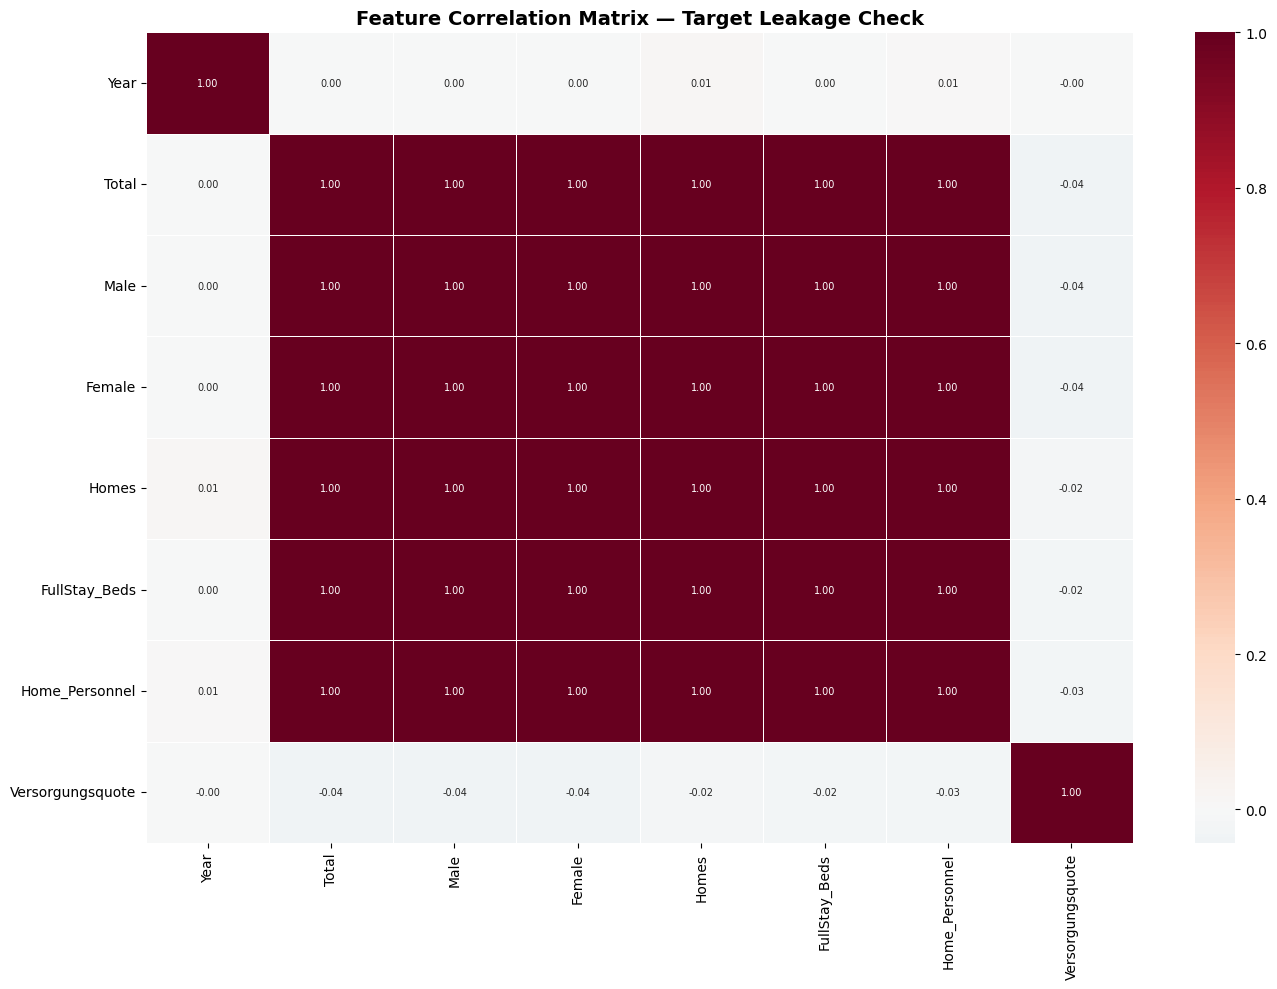


🚨 Correlation with Versorgungsquote (Target Variable):


Year             -0.004822
Homes            -0.021647
FullStay_Beds    -0.024924
Home_Personnel   -0.029681
Female           -0.042923
Total            -0.043064
Male             -0.043208
Name: Versorgungsquote, dtype: float64

In [10]:
# Correlation Heatmap — Evidence of Target Leakage

import matplotlib.pyplot as plt
import seaborn as sns

# Select only numeric columns for correlation
numeric_cols = df_master_full.select_dtypes(include='number').columns
corr_matrix = df_master_full[numeric_cols].corr()

# Plot heatmap
fig, ax = plt.subplots(figsize=(14, 10))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, linewidths=0.5, ax=ax,
            annot_kws={'size': 7})
ax.set_title('Feature Correlation Matrix — Target Leakage Check',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../../dataset/processed/correlation_heatmap.png',
            dpi=150, bbox_inches='tight')
plt.show()

# Highlight dangerous correlations with Versorgungsquote
print("\n🚨 Correlation with Versorgungsquote (Target Variable):")
target_corr = corr_matrix['Versorgungsquote'].drop('Versorgungsquote').sort_values(ascending=False)
display(target_corr)


---
## Step 4: Export Final Datasets
Save two files to `dataset/processed/`:
1. **`master_dataset.csv`** — For XGBoost (biennial, with INKAR features)  
2. **`population_annual.csv`** — For Prophet (annual 2015–2024, population only)

> **Important:** When loading these files in future notebooks, always use:  
> `pd.read_csv(..., dtype={'AGS': str})` followed by `.str.zfill(5)` to preserve leading zeros.

In [11]:
# -------------------------------------------------------------------
# 4. Export both datasets to the processed folder
# -------------------------------------------------------------------
processed_dir = '../../dataset/processed'
os.makedirs(processed_dir, exist_ok=True)

# 4a. Master dataset (XGBoost-ready)
master_path = f"{processed_dir}/master_dataset.csv"
df_master_full.to_csv(master_path, index=False)

# 4b. Annual population data (Prophet-ready)
pop_path = f"{processed_dir}/population_annual.csv"
df_pop_grouped.to_csv(pop_path, index=False)

print("✅==========================================✅")
print(f"   Master dataset saved  : {master_path}")
print(f"   Size                  : {os.path.getsize(master_path) / 1024:.1f} KB")
print(f"   Shape                 : {df_master_full.shape}")
print(f"")
print(f"   Population data saved : {pop_path}")
print(f"   Size                  : {os.path.getsize(pop_path) / 1024:.1f} KB")
print(f"   Shape                 : {df_pop_grouped.shape}")
print("✅==========================================✅")

✅==========================================✅
   Master dataset saved  : ../../dataset/processed/master_dataset.csv
   Size                  : 510.1 KB
   Shape                 : (2251, 25)

   Population data saved : ../../dataset/processed/population_annual.csv
   Size                  : 305.6 KB
   Shape                 : (4513, 6)
✅==========================================✅
